<h1 align="center">One Week Online Workshop on Statistics and 
    Machine Learning in Practice</h1>

<h1 align="center"><font color='gray'>Spectral clustering in R</font></h1>
<h3 align="center">Aparajita Khan</h3>
<h3 align="center">Indian Statistical Institute</h3>
<h4 align="center">
<a href="https://aparajita-k.github.io">https://aparajita-k.github.io</a></h4>
<h4 align="center">E-mail: aparajitakhan1107@gmail.com</h4>
<h4 align="center">July 29, 2020</h4>

## Spectral clustering
A unsupervised algorithm for graph based clustering


### Sampling data from Gaussian Distribution

 Glimpse of Dataset X: 
         [,1]     [,2]
[1,] 4.018564 4.591929
[2,] 4.170941 4.135924
[3,] 5.104749 3.765176
[4,] 4.941161 5.134738
[5,] 5.049414 4.611080

 Dimension of Dataset:   Samples: 500 	 Features: 2

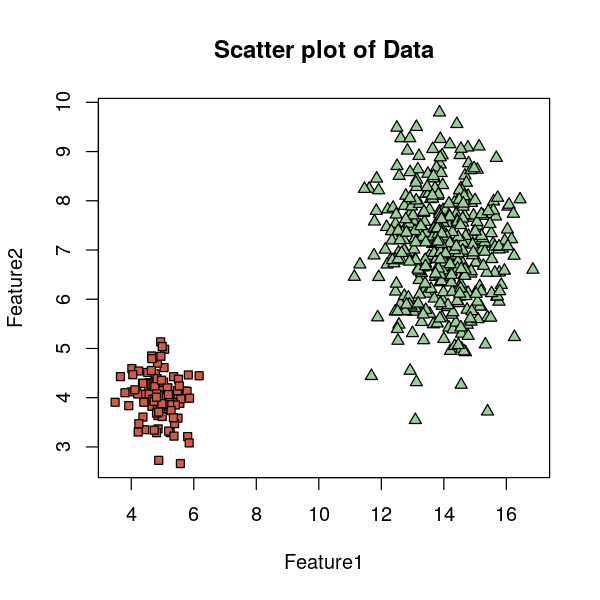

In [1]:
n1=100; n2=400;
Ca<-cbind(rnorm(n1,mean=5,sd=0.5),rnorm(n1,mean=4,sd=0.5))
Cb<-cbind(rnorm(n2,mean=14,sd=1),rnorm(n2,mean=7,sd=1))
X<-rbind(Ca,Cb)
cat(crayon::bold(" Glimpse of Dataset X: \n"))
print(X[1:5,])
cat(crayon::bold("\n Dimension of Dataset: ")," Samples:",dim(X)[1],"\t Features:",dim(X)[2])
true=c(rep(1,n1),rep(2,n2))
colvec = c("coral3","darkseagreen3")[true]
pchs= c(22,24)[true]
options(repr.plot.width=5, repr.plot.height=5)
plot(X,col="black",bg=colvec,pch=pchs,xlab="Feature1",ylab="Feature2",main="Scatter plot of Data")

n=dim(X)[1]

### Contructing a similarity matrix

$\mathbf{W}_{ij} = \exp\left(-\frac{\parallel x_i -x_j \parallel^2}{2 \sigma^2}\right)$


Dimension of W:  500 x 500
Pairwise similarity W[ 1 : 5 , 1 : 5 ]

          [,1]      [,2]      [,3]      [,4]      [,5]
[1,] 1.0000000 0.9715185 0.7922211 0.8665563 0.8755727
[2,] 0.9715185 1.0000000 0.8814549 0.8196658 0.8827741
[3,] 0.7922211 0.8814549 1.0000000 0.7883543 0.9140893
[4,] 0.8665563 0.8196658 0.7883543 1.0000000 0.9648892
[5,] 0.8755727 0.8827741 0.9140893 0.9648892 1.0000000

Pairwise similarity W[ 1 : 5 , 98 : 102 ]

          [,1]      [,2]      [,3]         [,4]         [,5]
[1,] 0.8138721 0.5903540 0.8276078 1.738601e-05 2.570192e-05
[2,] 0.8780848 0.7330027 0.9186469 1.952721e-05 2.517422e-05
[3,] 0.9881006 0.8685041 0.9930914 1.151660e-04 1.213397e-04
[4,] 0.8597107 0.4843967 0.7753494 1.601333e-04 2.462875e-04
[5,] 0.9608542 0.6394583 0.8999950 1.639582e-04 2.171011e-04

Heatmap of similarity matrix:


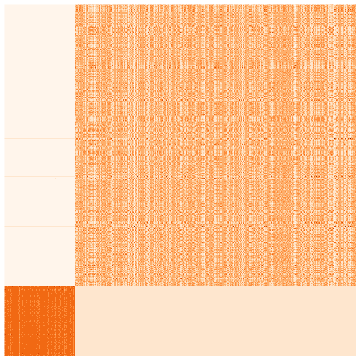

In [2]:
Similarity<-function(Dmat,rbfsg=2)
{
     show=5
     n=dim(Dmat)[1]
     W=matrix(0,n,n)
     for(i in 1:n)
        for(j in 1:i)
             W[i,j]=W[j,i]=exp(-sum((Dmat[i,]-Dmat[j,])^2)/(2*rbfsg*rbfsg))
    return(W)
    
}


W=Similarity(X)
cat(crayon::bold("\nDimension of W: "),dim(W)[1],"x",dim(W)[2])
rs=1;re=5;cs=1;ce=5
cat(crayon::bold("\nPairwise similarity W[",rs,":",re,",",cs,":",ce,"]\n\n"))
print(W[rs:re,cs:ce])

rs=1;re=5;cs=98;ce=102
cat(crayon::bold("\nPairwise similarity W[",rs,":",re,",",cs,":",ce,"]\n\n"))
print(W[rs:re,cs:ce])

library(RColorBrewer)
library(repr)
options(repr.plot.width=3, repr.plot.height=3)
cat(crayon::bold("\nHeatmap of similarity matrix:\n"))
heatmap(W,Colv = NA, Rowv = NA,labRow = FALSE, labCol = FALSE, margins=c(0.2,0.2),col=brewer.pal(9,"Oranges"))


### Computing the normalized graph Laplacian

$\mathbf{L} = \mathbf{D}^{-\frac{1}{2}} (\mathbf{D} - \mathbf{W}) \mathbf{D}^{-\frac{1}{2}} = \mathbf{I}_n - \mathbf{D}^{-\frac{1}{2}} \mathbf{W} \mathbf{D}^{-\frac{1}{2}}$


Dimension of L:  500 x 500
Normalized Laplacian L[ 1 : 5 , 1 : 5 ]

             [,1]         [,2]         [,3]         [,4]         [,5]
[1,]  0.987962988 -0.011326892 -0.009005186 -0.010517952 -0.010098994
[2,] -0.011326892  0.988707224 -0.009704819 -0.009636343 -0.009862261
[3,] -0.009005186 -0.009704819  0.989265696 -0.009036150 -0.009956396
[4,] -0.010517952 -0.009636343 -0.009036150  0.987760881 -0.011222227
[5,] -0.010098994 -0.009862261 -0.009956396 -0.011222227  0.988947688

Normalized Laplacian L[ 1 : 5 , 98 : 102 ]

             [,1]         [,2]         [,3]          [,4]          [,5]
[1,] -0.009234941 -0.007375496 -0.009404584 -1.129546e-07 -1.719610e-07
[2,] -0.009650625 -0.008870035 -0.010111245 -1.228811e-07 -1.631404e-07
[3,] -0.010587824 -0.010246563 -0.010656924 -7.065708e-07 -7.666460e-07
[4,] -0.009836622 -0.006102329 -0.008884402 -1.049062e-06 -1.661585e-06
[5,] -0.010447266 -0.007655228 -0.009799916 -1.020714e-06 -1.391854e-06

Heatmap of graph Laplacian:


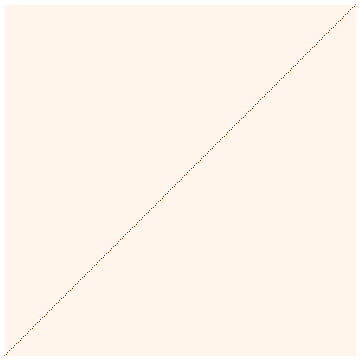

In [3]:
Laplacian<-function(W)
{
     n=dim(W)[1]
     D=rowSums(W)
     DH=diag(D^(-0.5))
     WN=DH%*%W%*%DH
     I=diag(n)
     L=I-WN
     return(list(L=L,D=D,WN=WN))
}

L=Laplacian(W)$L
cat(crayon::bold("\nDimension of L: "),dim(L)[1],"x",dim(L)[2])
rs=1;re=5;cs=1;ce=5
cat(crayon::bold("\nNormalized Laplacian L[",rs,":",re,",",cs,":",ce,"]\n\n"))
print(L[rs:re,cs:ce])
rs=1;re=5;cs=98;ce=102
cat(crayon::bold("\nNormalized Laplacian L[",rs,":",re,",",cs,":",ce,"]\n\n"))
print(L[rs:re,cs:ce])

options(repr.plot.width=3, repr.plot.height=3)
cat(crayon::bold("\nHeatmap of graph Laplacian:\n"))
heatmap(L,Colv = NA, Rowv = NA,labRow = FALSE, labCol = FALSE, margins=c(0.2,0.2),col=brewer.pal(9,"Oranges"))

### Eigendecomposition of Laplacian
$\mathbf{L} = U \Sigma U^T$

In [4]:
eg=eigen(L)
eVals=eg$values
eVecs=eg$vectors
cat(crayon::bold("\nNumber of eigenvalues of L: "), length(eVals))
sh=5
cat(crayon::bold("\nEigenvalues of L: "),eVals[1:sh],"...",eVals[(n-sh+1):n])

cat(crayon::bold("\n\nSmallest eigenvalue of L: ",eVals[n]))
cat(crayon::bold("\nSecond smallest eigenvalue of L: ",eVals[n-1]))

cat(crayon::bold("\n\nThird smallest eigenvalue of L: ",eVals[n-2]))


Number of eigenvalues of L:  500
Eigenvalues of L:  1 1 1 1 1 ... 0.9327797 0.7989285 0.7830876 0.0005847536 1.256581e-15

Smallest eigenvalue of L:  1.2565813191018e-15
Second smallest eigenvalue of L:  0.000584753575722628

Third smallest eigenvalue of L:  0.783087594361634

### Smallest eigenvalue-eigenvector of Laplacian

$1. \text{  All the eigenvalues are} \geq 0$

$2. \text{  } 
\mathbf{D}^{-\frac{1}{2}} \mathbf{1} \text{ is an eigenvector of } \mathbf{L}
\text{ with eigenvalue 0}$


In [5]:
D=Laplacian(W)$D
DH=diag(D^(0.5))

cat(crayon::bold("\n\nSmallest eigenvalue of L: ",eVals[n]))

rs=1;re=5;cs=1;ce=5
cat(crayon::bold("\nPairwise similarity W[",rs,":",re,",",cs,":",ce,"]\n\n"))
print(W[rs:re,cs:ce])
cat(crayon::bold("\nDegree values di's: "),D[1:5])

cat(crayon::bold("\nMatrix D^{1/2}: \n"))
print(DH[rs:re,cs:ce])

nrm=sqrt(sum(diag(DH)^2))
DH=DH/nrm
cat(crayon::bold("\nMatrix D^{1/2} with diagonal being unit norm: \n"))
print(DH[rs:re,cs:ce])

cat(crayon::bold("\nSmallest eigenvector of L: \n"))
print(eVecs[1:5,n, drop=FALSE])



Smallest eigenvalue of L:  1.2565813191018e-15
Pairwise similarity W[ 1 : 5 , 1 : 5 ]

          [,1]      [,2]      [,3]      [,4]      [,5]
[1,] 1.0000000 0.9715185 0.7922211 0.8665563 0.8755727
[2,] 0.9715185 1.0000000 0.8814549 0.8196658 0.8827741
[3,] 0.7922211 0.8814549 1.0000000 0.7883543 0.9140893
[4,] 0.8665563 0.8196658 0.7883543 1.0000000 0.9648892
[5,] 0.8755727 0.8827741 0.9140893 0.9648892 1.0000000

Degree values di's:  83.0771 88.55218 93.15928 81.70523 90.47881
Matrix D^{1/2}: 
         [,1]     [,2]     [,3]     [,4]     [,5]
[1,] 9.114664 0.000000 0.000000 0.000000 0.000000
[2,] 0.000000 9.410217 0.000000 0.000000 0.000000
[3,] 0.000000 0.000000 9.651905 0.000000 0.000000
[4,] 0.000000 0.000000 0.000000 9.039095 0.000000
[5,] 0.000000 0.000000 0.000000 0.000000 9.512035

Matrix D^{1/2} with diagonal being unit norm: 
          [,1]       [,2]       [,3]       [,4]       [,5]
[1,] 0.0270254 0.00000000 0.00000000 0.00000000 0.00000000
[2,] 0.0000000 0.02790173 0.0000

### Second smallest eigenvalue-eigenvector of Laplacian

$\lambda_2 = \underset{z \in \Re^{n}} {\mathrm{minimize}} \text{ }
\frac{z^T \mathbf{L} z}{z^T z} 
\text{ such that } z^T \left(\mathbf{D}^{\frac{1}{2}} \mathbf{1}\right) = 0$

$u_2 = \underset{z \in \Re^{n}} {\text{arg min}} \text{ }
\frac{z^T \mathbf{L} z}{z^T z} 
\text{ such that } z^T \left(\mathbf{D}^{\frac{1}{2}} \mathbf{1}\right) = 0$



Second smallest eigenvalue of L:  0.000584753575722628
Second smallest eigenvector of L: 
            [,1]
[1,] -0.09259940
[2,] -0.09560145
[3,] -0.09801449
[4,] -0.09176051
[5,] -0.09657085


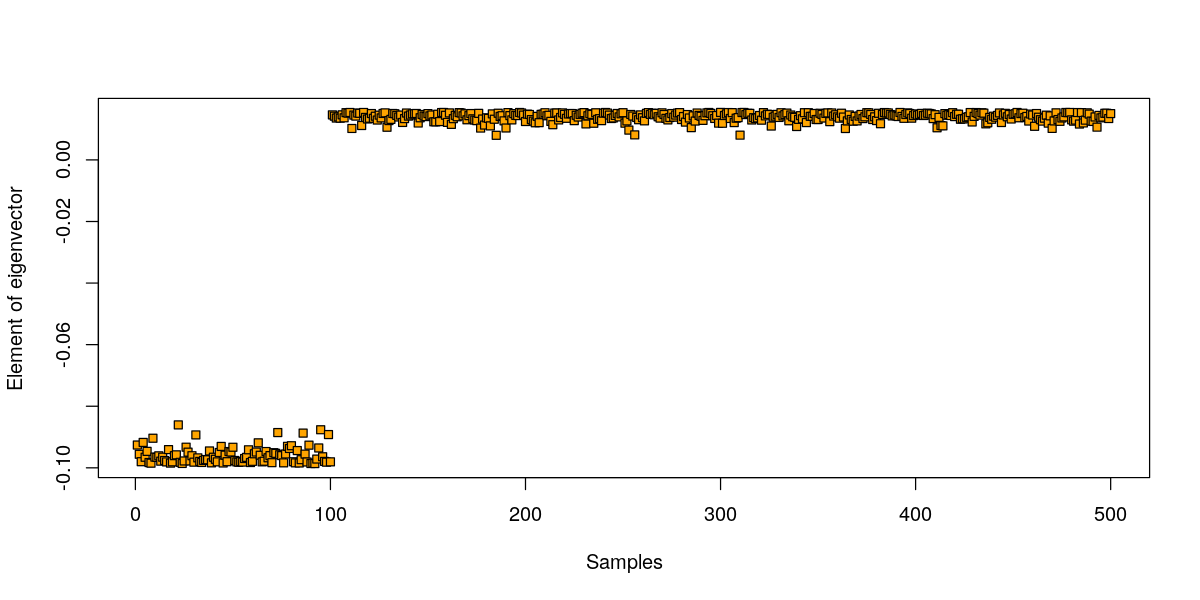

In [6]:
cat(crayon::bold("\n\nSecond smallest eigenvalue of L: ",eVals[n-1]))

cat(crayon::bold("\nSecond smallest eigenvector of L: \n"))
print(eVecs[1:5,n-1, drop=FALSE])

u2=eVecs[,n-1]
options(repr.plot.width=10, repr.plot.height=5)
plot(seq(1,n),u2,pch=22,xlab="Samples",ylab="Element of eigenvector",col="black",bg="orange")

### $k$-Means clustering on second smallest eigenvector


Cluster assignments: 
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

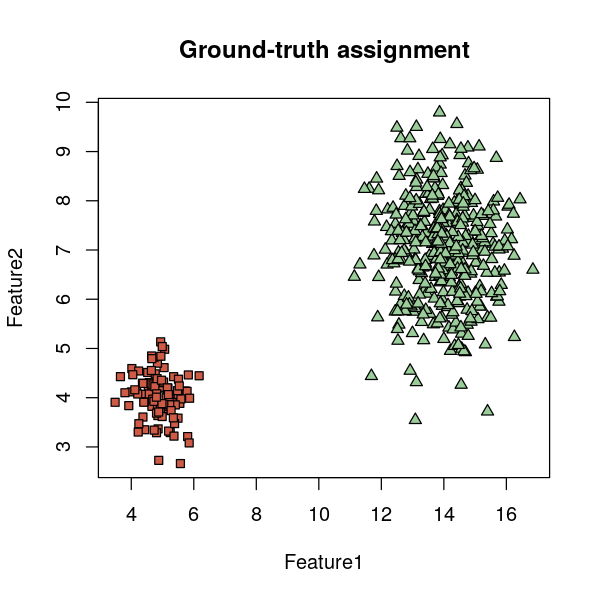

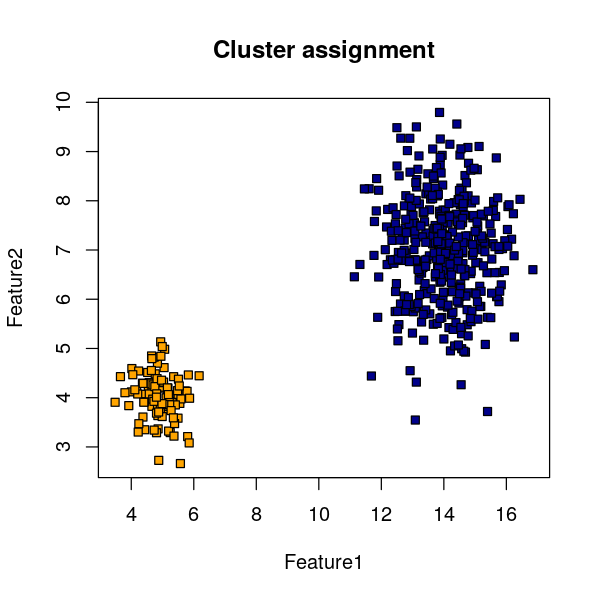

In [7]:
lowRank=eVecs[,n-1,drop=FALSE]
km=kmeans(lowRank,2,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments: \n"), km$cluster)

colvec = c("coral3","darkseagreen3")[true]
pchs= c(22,24)[true]
options(repr.plot.width=5, repr.plot.height=5)
plot(X,col="black",bg=colvec,pch=pchs,xlab="Feature1",ylab="Feature2",main="Ground-truth assignment")

colvec = c("darkblue","orange")[ km$cluster]
options(repr.plot.width=5, repr.plot.height=5)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment")

### Cluster evaluation using Rand index and adjusted Rand index

In [8]:
randind<-function(true, clust)
{
	n=length(true)
	n11=0
	n10=0
	n01=0
	n00=0
	for(i in 1:(n-1))
	{
		for(j in (i+1):n)
		{
			if((true[i]==true[j])&(clust[i]==clust[j]))
				n11=n11+1
			if((true[i]==true[j])&(clust[i]!=clust[j]))
				n10=n10+1
			if((true[i]!=true[j])&(clust[i]==clust[j]))
				n01=n01+1
			if((true[i]!=true[j])&(clust[i]!=clust[j]))
				n00=n00+1
		}
	}
	Rand=(n11+n00)/(n11+n10+n01+n00)
	ARI=(2*(n00*n11-n01*n10))/((n00+n01)*(n01+n11)+(n00+n10)*(n10+n11))
	return(list(Rand=Rand,ARI=ARI))
}

eval=randind(true, km$cluster)
cat(crayon::bold("\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))


Rand index:  1 		ARI:  1

## <font color='gray'> Spectral clustering vs $k$-Means clustering </font>

### The concentric circles dataset


Dimension of Data:  500 2
Dim Label= 500
Glimpse of Dataset X: 
           V1       V2
[1,]  0.96567 -0.10833
[2,] -1.02348 -0.37306
[3,] -0.02358 -0.95438
[4,]  0.86091 -0.60854
[5,] -0.18964 -1.03578

 Dimension of Dataset:   Samples: 500 	 Features: 2

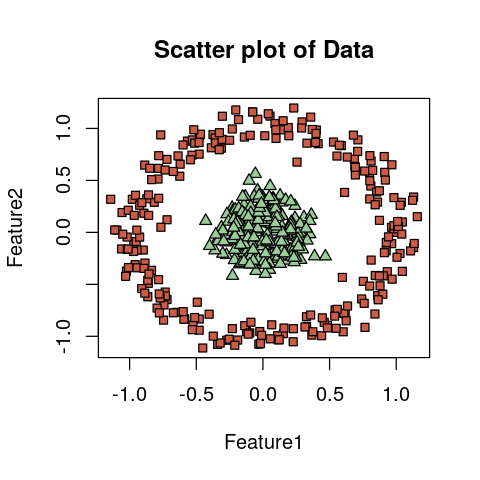

In [9]:
X <- as.matrix(read.table("CircleData", sep=" ", header=FALSE, row.names=NULL))
cat("\nDimension of Data: ",dim(X))
true <- as.numeric(readLines("CircleLabels"))
cat("\nDim Label=",length(true))
true=true+1
n=dim(X)[1]

srt=sort(true, index.return=TRUE)
true=srt$x
index=srt$ix
X=X[index,]


cat(crayon::bold("\nGlimpse of Dataset X: \n"))
print(X[1:5,])
cat(crayon::bold("\n Dimension of Dataset: ")," Samples:",dim(X)[1],"\t Features:",dim(X)[2])
colvec = c("coral3","darkseagreen3")[true]
pchs= c(22,24)[true]
options(repr.plot.width=4, repr.plot.height=4)
plot(X,col="black",bg=colvec,pch=pchs,xlab="Feature1",ylab="Feature2",main="Scatter plot of Data")

### Performing $k$-Means clustering


Cluster assignments for k-Means: 
 1 2 2 2 2 1 1 1 1 1 2 1 1 1 2 1 2 2 2 1 1 2 1 2 1 1 1 2 2 2 2 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 2 2 2 2 1 2 2 2 1 2 2 1 2 2 1 1 1 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 2 1 1 1 1 1 2 1 2 1 2 2 2 1 2 1 1 2 2 1 2 1 2 1 1 1 2 1 2 1 1 1 1 1 2 2 1 2 1 2 2 1 1 2 2 2 2 2 1 1 2 2 2 2 1 1 2 1 2 1 1 2 1 2 2 1 2 1 1 2 1 2 2 2 1 1 2 1 2 2 1 2 2 2 1 1 1 1 1 2 2 2 2 1 2 2 2 1 2 2 1 1 1 2 2 2 1 2 1 2 2 1 1 1 1 1 1 2 1 2 1 1 2 1 2 2 1 2 1 2 2 2 1 2 2 1 1 1 1 2 2 2 2 1 1 2 2 2 1 1 2 2 2 1 1 2 2 1 2 1 2 2 2 1 1 2 1 2 2 1 1 1 1 1 2 2 2 1 2 2 1 1 2 2 1 1 2 1 1 2 2 2 1 2 1 1 1 1 2 1 2 2 1 2 2 2 1 1 2 2 2 2 1 2 1 1 2 1 1 2 1 1 1 1 2 2 2 2 1 2 1 2 2 2 2 1 2 1 2 1 1 2 1 2 1 2 2 1 2 1 2 2 2 1 1 1 1 2 2 2 2 2 2 1 1 2 2 2 2 2 1 1 1 1 1 2 2 2 2 1 2 1 1 1 2 1 2 1 2 1 1 1 1 1 1 1 2 2 1 1 2 2 1 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 1 1 1 2 1 1 1 1 2 2 1 1 1 1 1 1 1 2 1 2 2 2 1 1 2 1 1 2 1 2 2 1 2 2 2 2 2 2 1 2 2 1 2 2 1 2 2 2 2 2 2 2 1 2 2 1 2 2 2 1 1 1 1 1 2 1 1 2 2 1 1 1 2 1 2 2 

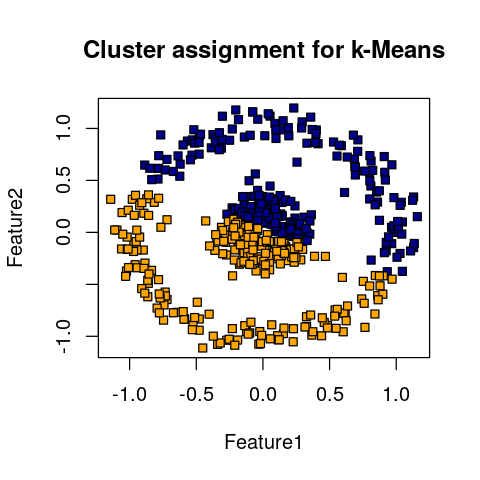

In [10]:
km=kmeans(X,2,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for k-Means: \n"), km$cluster)
colvec = c("darkblue","orange")[ km$cluster]
options(repr.plot.width=4, repr.plot.height=4)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for k-Means")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor k-Means\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

### Contructing a similarity matrix

__Using $k$ Nearest Neighbors similarity__


Heatmap of similarity matrix:


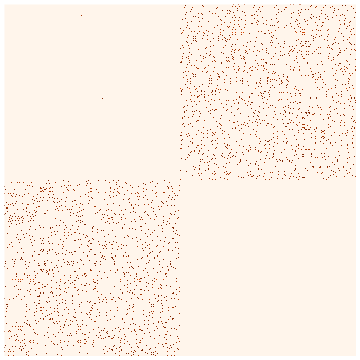

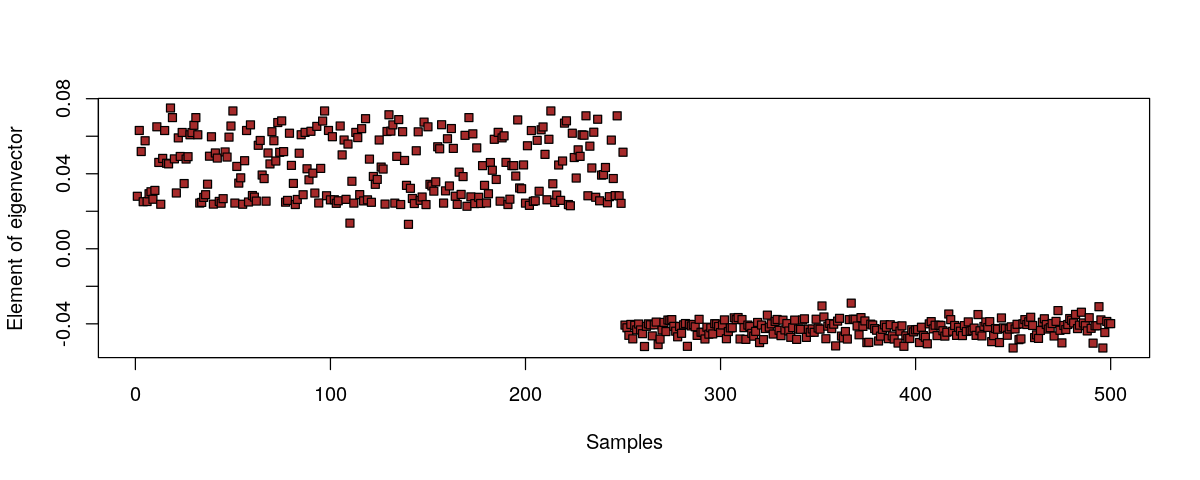

In [11]:
SimilarityKNN<-function(X,nn=10)
{
    D <- as.matrix(dist(X)) # matrix of euclidean distances between data points in X
    knn_mat <- matrix(0,nrow = nrow(X),ncol = nrow(X))  
    # find the 10 nearest neighbors for each point
    for (i in 1: nrow(X)) {
      neighbor_index <- order(D[i,])[2:(nn + 1)]
      knn_mat[i,][neighbor_index] <- 1 
    }
   
    #  xi and xj are neighbors iff K[i,j] = 1 or K[j,i] = 1 
    knn_mat <- knn_mat + t(knn_mat) # find mutual knn
    
    knn_mat[ knn_mat == 2 ] = 1
    return(knn_mat)
    
}



W=SimilarityKNN(X)
library(RColorBrewer)
options(repr.plot.width=3, repr.plot.height=3)
cat(crayon::bold("\nHeatmap of similarity matrix:\n"))
heatmap(W,Colv = NA, Rowv = NA,labRow = FALSE, labCol = FALSE, margins=c(0.2,0.2),col=brewer.pal(9,"Oranges"))

L=Laplacian(W)$L
eg=eigen(L)
eVals=eg$values
eVecs=eg$vectors
u2=eVecs[,n-1]
options(repr.plot.width=10, repr.plot.height=4)
plot(seq(1,n),u2,pch=22,xlab="Samples",ylab="Element of eigenvector",col="black",bg="brown")



Cluster assignments for spectral clustering: 
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

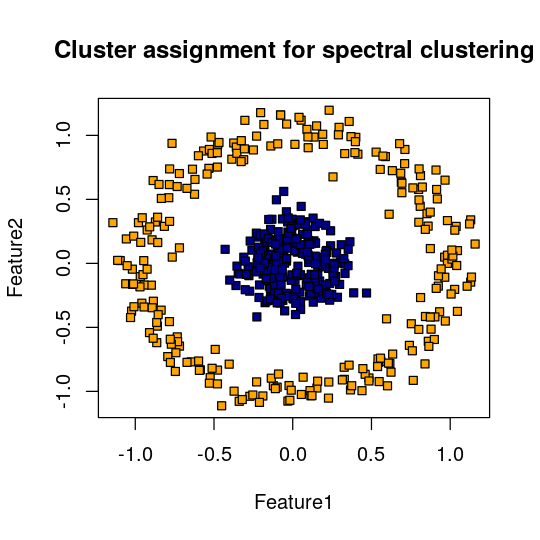

In [12]:
lowRank=eVecs[,n-1,drop=FALSE]
km=kmeans(lowRank,2,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for spectral clustering: \n"), km$cluster)
colvec = c("darkblue","orange")[ km$cluster]
options(repr.plot.width=4.5, repr.plot.height=4.5)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for spectral clustering")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor spectral clustering\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

### The Half Moon dataset


Dimension of Data:  100 2
Dim Label= 100
Glimpse of Dataset X: 
           V1      V2
[1,]  0.87132 0.49072
[2,] -0.22252 0.97493
[3,]  1.00000 0.00000
[4,]  0.94906 0.31511
[5,]  0.96729 0.25365

 Dimension of Dataset:   Samples: 100 	 Features: 2

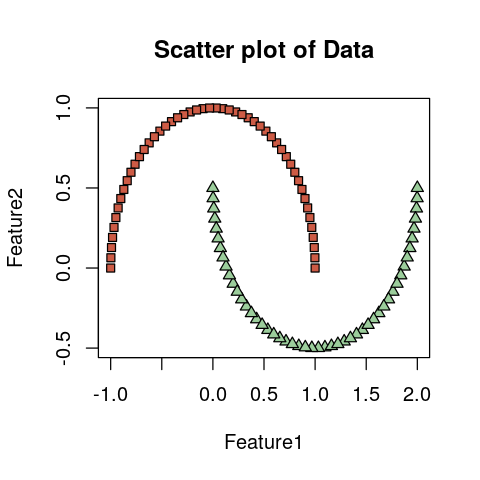

In [13]:
X <- as.matrix(read.table("HalfMoonData", sep=" ", header=FALSE, row.names=NULL))
cat("\nDimension of Data: ",dim(X))
true <- as.numeric(readLines("HalfMoonLabels"))
cat("\nDim Label=",length(true))
true=true+1
n=dim(X)[1]

srt=sort(true, index.return=TRUE)
true=srt$x
index=srt$ix
X=X[index,]


cat(crayon::bold("\nGlimpse of Dataset X: \n"))
print(X[1:5,])
cat(crayon::bold("\n Dimension of Dataset: ")," Samples:",dim(X)[1],"\t Features:",dim(X)[2])
colvec = c("coral3","darkseagreen3")[true]
pchs= c(22,24)[true]
options(repr.plot.width=4, repr.plot.height=4)
plot(X,col="black",bg=colvec,pch=pchs,xlab="Feature1",ylab="Feature2",main="Scatter plot of Data")

### Performing k-Means


Cluster assignments for k-Means: 
 1 2 1 1 1 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 1 1 2 2 2 2 1 2 2 2 2 2 2 2 1 1 2 2 2 1 2 2 1 2 2 2 2 2 2 2 1 1 1 2 1 1 1 2 1 2 1 1 1 1 2 1 1 1 1 1 1 2 1 2 1 1 2 2 1 1 1 2 1 1 2 2 1 1 1 2 1 1 1 1 1 1 2 1 1 1
For k-Means
Rand index:  0.611313131313131 		ARI:  0.22254693877551

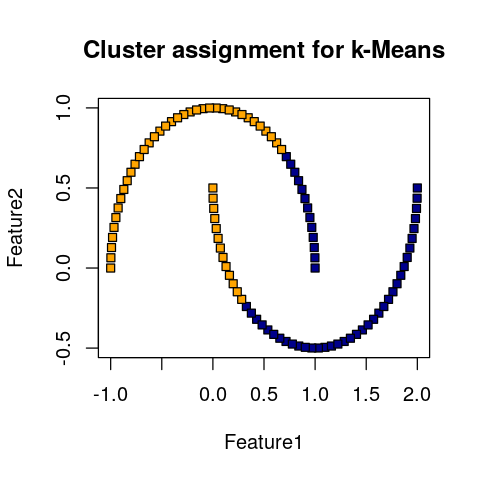

In [14]:
km=kmeans(X,2,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for k-Means: \n"), km$cluster)
colvec = c("darkblue","orange")[ km$cluster]
options(repr.plot.width=4, repr.plot.height=4)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for k-Means")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor k-Means\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

### Performing Spectral Clustering


Heatmap of similarity matrix:


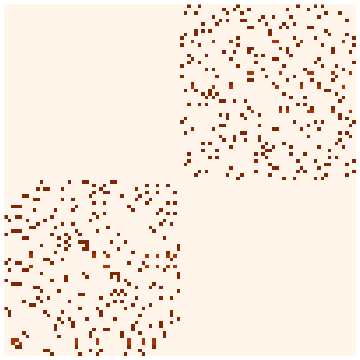


Cluster assignments for spectral clustering: 
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2

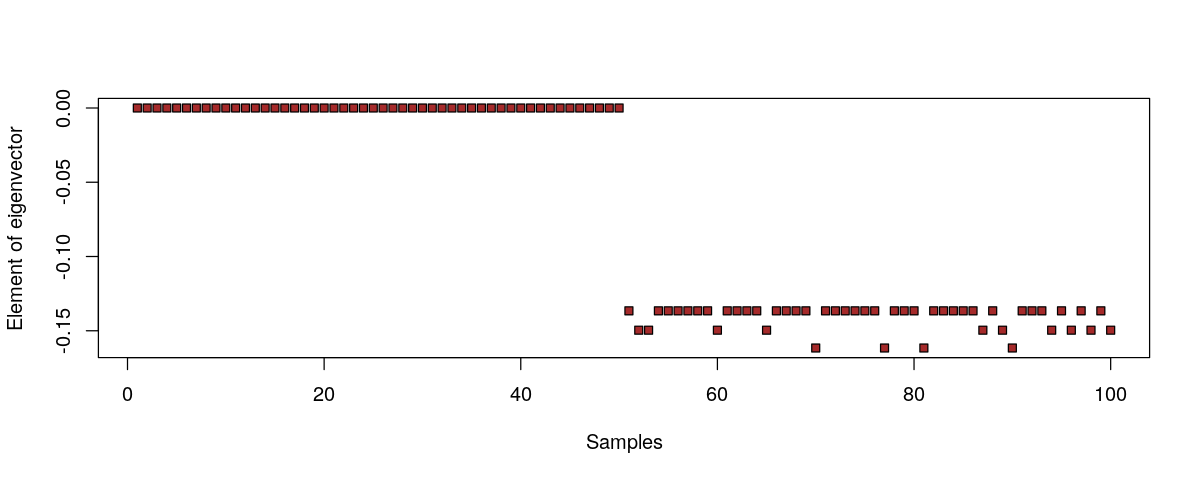


For spectral clustering
Rand index:  1 		ARI:  1

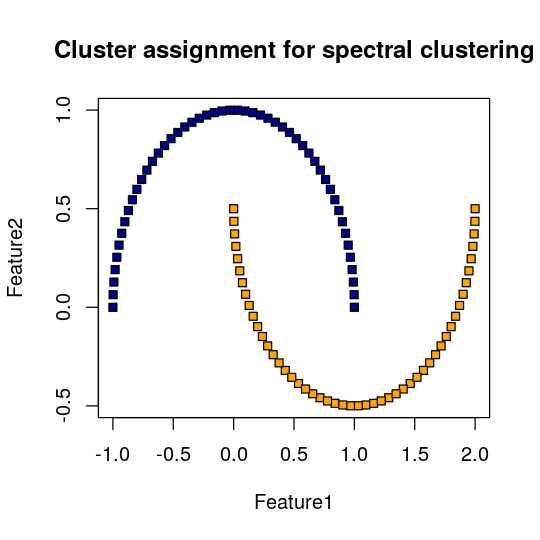

In [15]:
W=SimilarityKNN(X, nn=5)
library(RColorBrewer)
options(repr.plot.width=3, repr.plot.height=3)
cat(crayon::bold("\nHeatmap of similarity matrix:\n"))
heatmap(W,Colv = NA, Rowv = NA,labRow = FALSE, labCol = FALSE, margins=c(0.2,0.2),col=brewer.pal(9,"Oranges"))

L=Laplacian(W)$L
eg=eigen(L)
eVals=eg$values
eVecs=eg$vectors
u2=eVecs[,n-1]
options(repr.plot.width=10, repr.plot.height=4)
plot(seq(1,n),u2,pch=22,xlab="Samples",ylab="Element of eigenvector",col="black",bg="brown")


lowRank=eVecs[,n-1,drop=FALSE]
km=kmeans(lowRank,2,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for spectral clustering: \n"), km$cluster)
colvec = c("darkblue","orange")[ km$cluster]
options(repr.plot.width=4.5, repr.plot.height=4.5)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for spectral clustering")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor spectral clustering\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

## <font color='gray'> High-Dimensional Genomic Dataset </font>

### Lower Grade Glioma: Brain Cancer Dataset of The Cancer Genome Atlas (TCGA)

__TCGA identified 3 cancer subtypes in LGG based on DNA Methylation levels__

<a href="https://www.cancer.gov/about-nci/organization/ccg/research/structural-genomics/tcga/studied-cancers/glioma">https://www.cancer.gov/about-nci/organization/ccg/research/structural-genomics/tcga/studied-cancers/glioma</a>


In [16]:
X <- as.matrix(read.table("LGGDNA267",sep=" ",header=TRUE,row.names=1))
truedata=read.table("LGGLabels267",stringsAsFactors=FALSE)
true=as.vector(truedata[,2],mode="numeric")
n=dim(X)[1]
k=max(true)

srt=sort(true, index.return=TRUE)
true=srt$x
index=srt$ix
X=X[index,]


Glimpse of Dataset X: 
             cg07346310 cg12315302 cg06963844 cg23091824 cg09772154
TCGA-CS-4938  0.9504020  0.8761692 0.74204330 0.11511750 0.45833290
TCGA-CS-4942  0.6746383  0.7751889 0.06403225 0.06988543 0.07092868
TCGA-CS-4943  0.9508505  0.9326872 0.57882210 0.90451910 0.33021500
TCGA-CS-4944  0.8002839  0.6713714 0.46727200 0.71909620 0.05381005
TCGA-CS-5393  0.8722203  0.3993063 0.09340859 0.72411920 0.08210447
TCGA-CS-6665  0.4471728  0.8049128 0.84997550 0.37837550 0.05650655
TCGA-CS-6666  0.8555628  0.9076044 0.93585040 0.49738070 0.08594181
TCGA-DB-5273  0.4246523  0.6345815 0.43230560 0.26635640 0.29500310
TCGA-DB-5275  0.9510481  0.8408495 0.82113130 0.83416500 0.11688760
TCGA-DB-5276  0.5064992  0.3138326 0.55073570 0.34582320 0.05619699

 Dimension of Dataset:   Samples: 267 	 Features/DNA locations: 2000

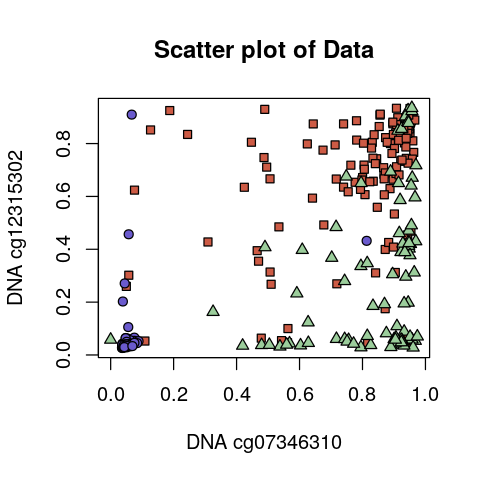

In [17]:
cat(crayon::bold("\nGlimpse of Dataset X: \n"))
print(X[1:10,1:5])

# X=log(1+X,base=10)
cat(crayon::bold("\n Dimension of Dataset: ")," Samples:",dim(X)[1],"\t Features/DNA locations:",dim(X)[2])
colvec = c("coral3","darkseagreen3","slateblue")[true]
pchs= c(22,24,21)[true]
options(repr.plot.width=4, repr.plot.height=4)
plot(X[,1:2],col="black",bg=colvec,pch=pchs,xlab="DNA cg07346310",ylab="DNA cg12315302",main="Scatter plot of Data")

### Performing k Means


Cluster assignments for k-Means: 
 3 3 2 3 3 3 3 3 2 3 3 3 2 3 3 3 2 3 2 3 3 2 3 3 3 3 3 3 3 2 3 3 3 3 3 2 3 3 3 2 2 2 2 3 3 3 2 3 3 3 3 3 3 3 3 2 2 2 3 3 2 3 3 3 2 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 2 3 3 3 3 3 3 2 2 3 3 3 3 2 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 2 2 3 2 2 3 2 3 2 2 2 2 3 2 3 3 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 2 2 3 3 3 2 2 2 3 3 3 3 2 3 2 3 2 2 3 3 3 3 2 3 3 3 2 2 2 3 2 3 2 3 2 2 3 2 2 2 2 3 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
For k-Means
Rand index:  0.743459773028076 		ARI:  0.457979601187244

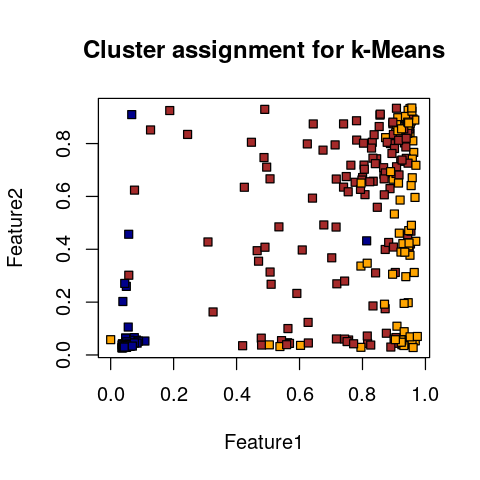

In [18]:
km=kmeans(X,3,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for k-Means: \n"), km$cluster)
colvec = c("darkblue","orange","brown")[ km$cluster]
options(repr.plot.width=4, repr.plot.height=4)
plot(X,col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for k-Means")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor k-Means\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

### Performing Spectral Clustering


Heatmap of similarity matrix:

Eigenvalues of Laplacian: 
 0.9999121 0.9998883 0.9998685 0.9998398 0.9998145
 indexes:  267 266 265 264 263 262
Cluster assignments for spectral clustering: 
 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

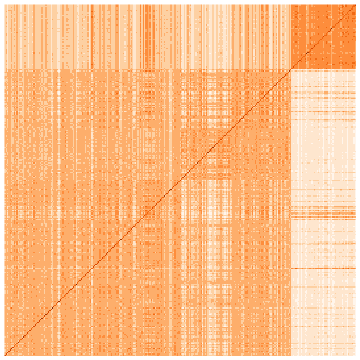


For spectral clustering
Rand index:  0.982765903522852 		ARI:  0.96341537134728

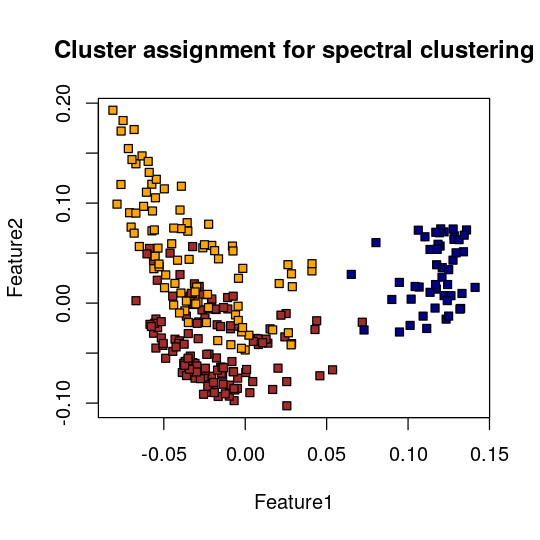

In [19]:
Datas=scale(X,center=T,scale=F)
Dist=max(as.numeric(dist(Datas)))
sigma=0.5*Dist
W=Similarity(X, rbfsg=sigma)
library(RColorBrewer)
options(repr.plot.width=3, repr.plot.height=3)
cat(crayon::bold("\nHeatmap of similarity matrix:\n"))
heatmap(W,Colv = NA, Rowv = NA,labRow = FALSE, labCol = FALSE, margins=c(0.2,0.2),col=brewer.pal(9,"Oranges"))


L=Laplacian(W)$L
eg=eigen(L)
eVals=eg$values
eVecs=eg$vectors

cat(crayon::bold("\nEigenvalues of Laplacian: \n"), eVals[1:5])
ind=seq(n,n-2*k+1)
cat("\n indexes: ",ind)
lowRank=eVecs[,ind,drop=FALSE]
km=kmeans(lowRank,3,iter.max=100,nstart=10)

cat(crayon::bold("\nCluster assignments for spectral clustering: \n"), km$cluster)
colvec = c("darkblue","orange","brown")[ km$cluster]
options(repr.plot.width=4.5, repr.plot.height=4.5)
plot(lowRank[,2:3],col="black",bg=colvec,pch=22,xlab="Feature1",ylab="Feature2",main="Cluster assignment for spectral clustering")

eval=randind(true, km$cluster)
cat(crayon::bold("\nFor spectral clustering\nRand index: ",eval$Rand,"\t\tARI: ",eval$ARI))

Tutorial: 
__U. Von Luxburg,“A tutorial on spectral clustering,” Statistics and Computing, vol.17, no. 4, pp. 395–416, 2007.__

<h1 align="center">Thank You</h1>

__Aparajita Khan__

__Senior Research Fellow__

__Indian Statistical Institute__

<a href="https://aparajita-k.github.io">https://aparajita-k.github.io</a>

E-mail: aparajitakhan1107@gmail.com